# Head-head social isolation testing

Exploratory comparison of head-head attraction-rig outputs across housing and feeding-pair conditions.

Initial scan to look at first:

- The clearest GH vs SI split is in `fed-starved`: GH has many more 1 mm contacts and longer bout duration than SI.
- Within SI, `fed-starved` is the quiet/low-contact condition: lower speed and fewer/shorter contacts than SI `fed-fed` or SI `starved-starved`.
- GH larvae are more mobile than SI larvae in matching feeding conditions, especially `fed-starved` and `starved-starved`.
- Approach probability is very similar across groups, so the more interesting story may be contact persistence/mobility rather than simple approach likelihood.

The notebook uses `included_files.csv` as the file universe and left-joins contact/bout summaries, so videos with zero contacts stay in the analysis.

In [1]:
from pathlib import Path
from itertools import combinations
import warnings

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = print

try:
    from scipy.stats import mannwhitneyu
    SCIPY_AVAILABLE = True
except Exception as exc:
    SCIPY_AVAILABLE = False
    warnings.warn(f"scipy unavailable; p-values will be NaN: {exc}")

BASE = Path('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates')
HOUSING_LABELS = {'group-housed': 'GH', 'socially-isolated': 'SI'}
FEEDING_ORDER = ['fed-fed', 'fed-starved', 'starved-starved']
CONDITION_ORDER = [
    'GH fed-fed', 'GH fed-starved', 'GH starved-starved',
    'SI fed-fed', 'SI fed-starved', 'SI starved-starved',
]
PALETTE = {
    'GH fed-fed': '#2F6F4E',
    'GH fed-starved': '#6E9F5B',
    'GH starved-starved': '#A9A23E',
    'SI fed-fed': '#2F5F8F',
    'SI fed-starved': '#8A63A8',
    'SI starved-starved': '#C85C5C',
    'GH': '#2F6F4E',
    'SI': '#2F5F8F',
}

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['figure.dpi'] = 120
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.right'] = False
pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 80)

In [2]:
def read_csv(path, **kwargs):
    path = Path(path)
    if not path.exists():
        return pd.DataFrame()
    try:
        return pd.read_csv(path, **kwargs)
    except pd.errors.EmptyDataError:
        return pd.DataFrame()


def condition_dirs(base=BASE):
    for housing_dir in sorted(base.iterdir()):
        if not housing_dir.is_dir() or housing_dir.name not in HOUSING_LABELS:
            continue
        for feeding_dir in sorted(housing_dir.iterdir()):
            if not feeding_dir.is_dir():
                continue
            housing = HOUSING_LABELS[housing_dir.name]
            feeding = feeding_dir.name
            yield housing_dir.name, housing, feeding, feeding_dir


def load_table(name, base=BASE):
    dfs = []
    for housing_raw, housing, feeding, folder in condition_dirs(base):
        df = read_csv(folder / name)
        if df.empty:
            continue
        df['housing_raw'] = housing_raw
        df['housing'] = housing
        df['feeding'] = feeding
        df['condition'] = f'{housing} {feeding}'
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()


def build_per_file_metrics(base=BASE):
    rows = []
    for housing_raw, housing, feeding, folder in condition_dirs(base):
        condition = f'{housing} {feeding}'

        included = read_csv(folder / 'included_files.csv')
        if included.empty:
            continue
        included['passed'] = included['passed_filter'].astype(str).str.upper().eq('Y')
        files = included.loc[included['passed'], ['file_name']].drop_duplicates().rename(columns={'file_name': 'file'})
        files['housing_raw'] = housing_raw
        files['housing'] = housing
        files['feeding'] = feeding
        files['condition'] = condition
        files['video_base'] = files['file'].str.replace('.tracks.feather', '', regex=False)

        file_summary = read_csv(folder / 'file_summary.csv')
        if not file_summary.empty:
            file_summary['video_base'] = file_summary['video_name'].astype(str)
            file_summary = file_summary.groupby('video_base').agg(
                n_tracks=('track', 'nunique'),
                any_left=('left', 'max'),
                n_left=('left', 'sum'),
                any_came_back=('came_back', 'max'),
                mean_track_frames=('total_number_frames', 'mean'),
            ).reset_index()
            files = files.merge(file_summary, on='video_base', how='left')

        contacts = read_csv(folder / 'closest_contacts_1mm.csv')
        if not contacts.empty:
            contacts['file'] = contacts['file'].astype(str)
            contacts_all = contacts.groupby('file').agg(
                contact_frames_1mm=('frame', 'nunique'),
                contact_rows_1mm=('frame', 'size'),
                min_contact_frame=('frame', 'min'),
                median_contact_distance=('Distance', 'median'),
            ).reset_index()
            head_head = contacts[contacts['Closest Interaction Type'].eq('head_head')]
            head_head = head_head.groupby('file').agg(
                head_head_frames_1mm=('frame', 'nunique'),
                min_head_head_frame=('frame', 'min'),
                median_head_head_distance=('Distance', 'median'),
            ).reset_index()
            type_counts = (
                contacts.pivot_table(
                    index='file', columns='Closest Interaction Type', values='frame',
                    aggfunc='size', fill_value=0,
                )
                .add_prefix('closest_type_frames_')
                .reset_index()
            )
            files = files.merge(contacts_all, on='file', how='left')
            files = files.merge(head_head, on='file', how='left')
            files = files.merge(type_counts, on='file', how='left')

        bouts = read_csv(folder / 'interaction_type_bout.csv')
        if not bouts.empty:
            bout_summary = bouts.groupby('file').agg(
                n_bouts=('bout_id', 'nunique'),
                total_bout_duration=('duration', 'sum'),
                mean_bout_duration=('duration', 'mean'),
                max_bout_duration=('duration', 'max'),
                first_bout_frame=('start_frame', 'min'),
            ).reset_index()
            for column, prefix in [('initial_type', 'initial_bouts'), ('predominant_type', 'predominant_bouts')]:
                pivot = (
                    bouts.pivot_table(index='file', columns=column, values='bout_id', aggfunc='size', fill_value=0)
                    .add_prefix(prefix + '_')
                    .reset_index()
                )
                bout_summary = bout_summary.merge(pivot, on='file', how='left')
            files = files.merge(bout_summary, on='file', how='left')

        pairwise = read_csv(folder / 'pairwise_approach_probability.csv')
        if not pairwise.empty:
            pairwise_summary = pairwise.groupby('file').agg(
                approach_probability=('approach', 'mean'),
                mean_delta_distance=('delta_distance', 'mean'),
                median_pair_distance=('distance', 'median'),
                n_approach_rows=('approach', 'size'),
            ).reset_index()
            files = files.merge(pairwise_summary, on='file', how='left')

        individual = read_csv(folder / 'individual_approach_probability.csv')
        if not individual.empty:
            individual_summary = individual.groupby('file').agg(
                individual_approach_probability=('approach', 'mean'),
                median_approach_angle=('approach_angle', 'median'),
                median_focal_speed=('focal_speed', 'median'),
                median_stim_speed=('stim_speed', 'median'),
                n_individual_approach_rows=('approach', 'size'),
            ).reset_index()
            files = files.merge(individual_summary, on='file', how='left')

        nearest = read_csv(
            folder / 'nearest_neighbour.csv',
            usecols=['file', 'frame', 'track_id', 'head_distance', 'closest_node_distance',
                     'body-body', 'speed', 'angle', 'digging_status', 'is_moving'],
        )
        if not nearest.empty:
            nearest_summary = nearest.groupby('file').agg(
                median_head_distance=('head_distance', 'median'),
                min_head_distance=('head_distance', 'min'),
                frac_head_within_5mm=('head_distance', lambda s: np.nanmean(s < 5)),
                frac_head_within_10mm=('head_distance', lambda s: np.nanmean(s < 10)),
                median_closest_node_distance=('closest_node_distance', 'median'),
                min_closest_node_distance=('closest_node_distance', 'min'),
                median_body_distance=('body-body', 'median'),
                median_speed=('speed', 'median'),
                moving_fraction=('is_moving', 'mean'),
                digging_fraction=('digging_status', 'mean'),
                median_angle=('angle', 'median'),
            ).reset_index()
            files = files.merge(nearest_summary, on='file', how='left')

        first_contact = read_csv(folder / 'head_head_first_contact_kinematics.csv')
        if not first_contact.empty:
            first0 = first_contact[first_contact['rel_frame'].eq(0)]
            first_summary = first0.groupby('file').agg(
                first_contact_speed_body=('speed_body', 'mean'),
                first_contact_speed_head=('speed_head', 'mean'),
                first_contact_heading_angle=('heading_angle', 'mean'),
                first_contact_min_distance=('min_distance', 'mean'),
            ).reset_index()
            files = files.merge(first_summary, on='file', how='left')

        before_leaving = read_csv(folder / 'interacted_before_leaving.csv')
        if not before_leaving.empty:
            leaving_summary = before_leaving.groupby('file').agg(
                left_in_ibl=('left', 'max'),
                interacted_before_leaving=('interacted_before_leaving', 'max'),
                n_bouts_before_leaving=('n_bouts_before_leaving', 'sum'),
                interaction_duration_before_leaving=('total_interaction_duration_before_leaving', 'sum'),
            ).reset_index()
            files = files.merge(leaving_summary, on='file', how='left')

        rows.append(files)

    metrics = pd.concat(rows, ignore_index=True)
    for column in metrics.columns:
        if column.startswith((
            'contact_frames', 'contact_rows', 'head_head_frames', 'closest_type_frames_',
            'n_bouts', 'total_bout_duration', 'initial_bouts_', 'predominant_bouts_',
            'n_approach_rows', 'n_individual_approach_rows', 'n_bouts_before_leaving',
            'interaction_duration_before_leaving',
        )):
            metrics[column] = metrics[column].fillna(0)
    for column in ['any_left', 'any_came_back', 'left_in_ibl', 'interacted_before_leaving']:
        if column in metrics:
            metrics[column] = metrics[column].fillna(False).astype(bool)
    return metrics


per_file = build_per_file_metrics()
condition_counts = per_file.groupby(['housing', 'feeding']).size().rename('n_files').reset_index()
display(condition_counts)
per_file.head()

,housing,feeding,n_files
0,GH,fed-fed,26
1,GH,fed-starved,28
2,GH,starved-starved,20
3,SI,fed-fed,25
4,SI,fed-starved,19
5,SI,starved-starved,19


,file,housing_raw,housing,feeding,condition,video_base,n_tracks,any_left,n_left,any_came_back,mean_track_frames,contact_frames_1mm,contact_rows_1mm,min_contact_frame,median_contact_distance,head_head_frames_1mm,min_head_head_frame,median_head_head_distance,closest_type_frames_body_body,closest_type_frames_body_head,closest_type_frames_body_tail,closest_type_frames_head_head,closest_type_frames_head_tail,closest_type_frames_tail_tail,n_bouts,total_bout_duration,mean_bout_duration,max_bout_duration,first_bout_frame,initial_bouts_body_head,initial_bouts_head_head,initial_bouts_head_tail,predominant_bouts_body_head,predominant_bouts_body_tail,predominant_bouts_head_head,predominant_bouts_head_tail,approach_probability,mean_delta_distance,median_pair_distance,n_approach_rows,individual_approach_probability,median_approach_angle,median_focal_speed,median_stim_speed,n_individual_approach_rows,median_head_distance,min_head_distance,frac_head_within_5mm,frac_head_within_10mm,median_closest_node_distance,min_closest_node_distance,median_body_distance,median_speed,moving_fraction,digging_fraction,median_angle,first_contact_speed_body,first_contact_speed_head,first_contact_heading_angle,first_contact_min_distance,left_in_ibl,interacted_before_leaving,n_bouts_before_leaving,interaction_duration_before_leaving,initial_bouts_body_body,initial_bouts_tail_tail,predominant_bouts_body_body,predominant_bouts_tail_tail,initial_bouts_body_tail
0,2026-05-18_12-02-50_td17.tracks.feather,group-housed,GH,fed-fed,GH fed-fed,2026-05-18_12-02-50_td17,2.0,False,0.0,False,3601.0,13,13,355.0,0.646541,6.0,355.0,0.659666,0.0,2.0,2.0,6.0,3.0,0.0,3.0,15.0,5.000000,10.0,355.0,0.0,2.0,1.0,0.0,1.0,2.0,0.0,0.476608,0.055820,6.610120,342,0.452862,89.799632,0.851600,0.861805,594,39.590146,0.278644,0.023466,0.082477,38.704443,0.278644,40.682375,0.847188,0.968064,0.0,170.858484,0.825118,0.646623,9.144052,0.675686,False,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2026-04-28_12-20-56_td13.tracks.feather,group-housed,GH,fed-fed,GH fed-fed,2026-04-28_12-20-56_td13,2.0,False,0.0,False,3600.0,0,1,NaN,NaN,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.430380,0.113613,8.432472,79,0.427350,78.211398,0.830325,0.833786,117,58.547167,3.290042,0.001389,0.016250,57.610284,3.290042,59.530122,0.765617,0.957361,0.0,169.974343,NaN,NaN,NaN,NaN,False,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2026-05-18_12-07-50_td20.tracks.feather,group-housed,GH,fed-fed,GH fed-fed,2026-05-18_12-07-50_td20,2.0,False,0.0,False,3600.0,50,50,421.0,0.509336,13.0,2265.0,0.482359,1.0,4.0,4.0,13.0,26.0,2.0,9.0,66.0,7.333333,20.0,421.0,0.0,3.0,6.0,1.0,1.0,1.0,6.0,0.455399,0.050067,5.281857,426,0.444149,88.402010,0.657870,0.646903,752,43.397200,0.020327,0.044167,0.104444,42.292888,0.020327,44.407839,0.806442,0.947778,0.0,169.608203,1.089691,1.364760,3.685892,0.153402,False,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2026-05-11_11-26-49_td19.tracks.feather,group-housed,GH,fed-fed,GH fed-fed,2026-05-11_11-26-49_td19,2.0,False,0.0,False,3600.0,43,43,1545.0,0.548928,3.0,1615.0,0.564839,0.0,2.0,7.0,3.0,26.0,5.0,5.0,55.0,11.000000,13.0,1545.0,0.0,2.0,3.0,0.0,0.0,0.0,5.0,0.481707,0.036883,4.418448,328,0.481967,103.325236,0.555278,0.585769,610,43.484306,0.228224,0.042778,0.084722,42.088043,0.228224,44.130554,0.718577,0.965972,0.0,170.506922,0.849235,0.806052,28.339531,0.230773,False,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2026-05-18_12-06-01_td19.tracks.feather,group-housed,GH,fed-fed,GH fed-fed,2026-05-18_12-06-01_td19,2.0,True,1.0,False,2524.5,2,2,333.0,0.901853,2.0,333.0,0.901853,0.0,0.0,0.0,2.0,0.0,0.0,1.0,2.0,2.000000,2.0,333.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.405405,0.107749,5.495318,37,0.378788,94.112902,0.736170,0.816010,66,60.629480,0.859043,0.005348,0.013072,59.985148,0.859043,61.598402,0.822648,0.962369,0.0,170.492274,0.271320,0.356250,12.302124,0.859043,True,True,1.0,1.0,0.0,0.0,0.0,0.0,0.0


In [3]:
summary_metrics = [
    'contact_frames_1mm', 'head_head_frames_1mm', 'n_bouts', 'total_bout_duration',
    'first_bout_frame', 'min_head_head_frame', 'approach_probability',
    'individual_approach_probability', 'median_head_distance', 'frac_head_within_5mm',
    'median_speed', 'moving_fraction', 'any_left', 'interacted_before_leaving',
    'first_contact_heading_angle', 'first_contact_speed_head',
]

median_summary = per_file.groupby(['housing', 'feeding'])[summary_metrics].median(numeric_only=True).round(3)
mean_summary = per_file.groupby(['housing', 'feeding'])[summary_metrics].mean(numeric_only=True).round(3)

display(median_summary)
display(mean_summary)

contact_frames_1mm  head_head_frames_1mm  n_bouts  \
housing feeding                                                              
GH      fed-fed                         9.5                   2.0      2.5   
        fed-starved                    15.5                   3.0      3.0   
        starved-starved                10.5                   1.0      2.0   
SI      fed-fed                         7.0                   2.0      2.0   
        fed-starved                     3.0                   1.0      2.0   
        starved-starved                 9.0                   2.0      3.0   

                         total_bout_duration  first_bout_frame  \
housing feeding                                                  
GH      fed-fed                         11.5            1073.5   
        fed-starved                     19.5             712.5   
        starved-starved                 14.5             774.0   
SI      fed-fed                         10.0             994.0   
        fed-starved                      4.0             842.5   
        starved-starved                 11.0             720.5   

                         min_head_head_frame  approach_probability  \
housing feeding                                                      
GH      fed-fed                       1296.0                 0.480   
        fed-starved                   1229.0                 0.472   
        starved-starved                870.5                 0.479   
SI      fed-fed                       1160.0                 0.474   
        fed-starved                   1070.5                 0.474   
        starved-starved                715.0                 0.477   

                         individual_approach_probability  \
housing feeding                                            
GH      fed-fed                                    0.462   
        fed-starved                                0.466   
        starved-starved                            0.474   
SI      fed-fed                                    0.484   
        fed-starved                                0.469   
        starved-starved                            0.468   

                         median_head_distance  frac_head_within_5mm  \
housing feeding                                                       
GH      fed-fed                        50.856                 0.020   
        fed-starved                    48.653                 0.022   
        starved-starved                44.276                 0.019   
SI      fed-fed                        42.605                 0.017   
        fed-starved                    41.688                 0.018   
        starved-starved                45.689                 0.019   

                         median_speed  moving_fraction  any_left  \
housing feeding                                                    
GH      fed-fed                 0.811            0.957       0.0   
        fed-starved             0.821            0.956       0.0   
        starved-starved         0.823            0.964       0.0   
SI      fed-fed                 0.807            0.947       1.0   
        fed-starved             0.717            0.941       0.0   
        starved-starved         0.757            0.946       0.0   

                         interacted_before_leaving  \
housing feeding                                      
GH      fed-fed                                0.0   
        fed-starved                            0.0   
        starved-starved                        0.0   
SI      fed-fed                                0.0   
        fed-starved                            0.0   
        starved-starved                        0.0   

                         first_contact_heading_angle  first_contact_speed_head  
housing feeding                                                                 
GH      fed-fed                               11.971                     0.852  
        fed-starved                    

contact_frames_1mm  head_head_frames_1mm  n_bouts  \
housing feeding                                                              
GH      fed-fed                      14.885                 3.462    3.308   
        fed-starved                  33.571                 9.393    4.857   
        starved-starved              16.850                 4.550    3.150   
SI      fed-fed                      11.680                 3.240    3.680   
        fed-starved                   5.263                 1.842    2.158   
        starved-starved              10.211                 2.421    2.895   

                         total_bout_duration  first_bout_frame  \
housing feeding                                                  
GH      fed-fed                       18.692          1143.150   
        fed-starved                   39.036           981.458   
        starved-starved               20.950           646.267   
SI      fed-fed                       14.920          1233.000   
        fed-starved                    6.474          1053.500   
        starved-starved               13.158           872.875   

                         min_head_head_frame  approach_probability  \
housing feeding                                                      
GH      fed-fed                     1524.056                 0.476   
        fed-starved                 1453.905                 0.488   
        starved-starved              861.000                 0.481   
SI      fed-fed                     1335.882                 0.470   
        fed-starved                  971.100                 0.475   
        starved-starved              871.909                 0.474   

                         individual_approach_probability  \
housing feeding                                            
GH      fed-fed                                    0.469   
        fed-starved                                0.476   
        starved-starved                            0.471   
SI      fed-fed                                    0.473   
        fed-starved                                0.471   
        starved-starved                            0.481   

                         median_head_distance  frac_head_within_5mm  \
housing feeding                                                       
GH      fed-fed                        50.124                 0.022   
        fed-starved                    46.447                 0.030   
        starved-starved                45.517                 0.024   
SI      fed-fed                        43.633                 0.022   
        fed-starved                    42.594                 0.023   
        starved-starved                45.761                 0.020   

                         median_speed  moving_fraction  any_left  \
housing feeding                                                    
GH      fed-fed                 0.799            0.956     0.269   
        fed-starved             0.801            0.954     0.321   
        starved-starved         0.837            0.963     0.300   
SI      fed-fed                 0.801            0.947     0.520   
        fed-starved             0.716            0.931     0.474   
        starved-starved         0.758            0.940     0.263   

                         interacted_before_leaving  \
housing feeding                                      
GH      fed-fed                              0.192   
        fed-starved                          0.214   
        starved-starved                      0.100   
SI      fed-fed                              0.400   
        fed-starved                          0.211   
        starved-starved                      0.158   

                         first_contact_heading_angle  first_contact_speed_head  
housing feeding                                                                 
GH      fed-fed                               14.585                     0.885  
        fed-starved                    

In [4]:
def cliffs_delta(x, y):
    x = np.asarray(pd.Series(x).dropna(), dtype=float)
    y = np.asarray(pd.Series(y).dropna(), dtype=float)
    if len(x) == 0 or len(y) == 0:
        return np.nan
    gt = sum((xi > y).sum() for xi in x)
    lt = sum((xi < y).sum() for xi in x)
    return (gt - lt) / (len(x) * len(y))


def mwu_p(x, y):
    x = pd.Series(x).dropna()
    y = pd.Series(y).dropna()
    if len(x) < 2 or len(y) < 2 or not SCIPY_AVAILABLE:
        return np.nan
    if x.nunique() == 1 and y.nunique() == 1 and x.iloc[0] == y.iloc[0]:
        return 1.0
    try:
        return mannwhitneyu(x, y, alternative='two-sided').pvalue
    except Exception:
        return np.nan


def bh_adjust(p_values):
    p = pd.Series(p_values, dtype=float)
    out = pd.Series(np.nan, index=p.index, dtype=float)
    valid = p.dropna().sort_values()
    m = len(valid)
    if m == 0:
        return out
    adjusted = valid * m / np.arange(1, m + 1)
    adjusted = adjusted.iloc[::-1].cummin().iloc[::-1].clip(upper=1)
    out.loc[adjusted.index] = adjusted
    return out


def compare_levels(data, group_col, levels, metric_list):
    rows = []
    for metric in metric_list:
        if metric not in data:
            continue
        for a, b in combinations(levels, 2):
            xa = data.loc[data[group_col].eq(a), metric]
            xb = data.loc[data[group_col].eq(b), metric]
            if xa.dropna().empty or xb.dropna().empty:
                continue
            rows.append({
                'metric': metric,
                'comparison': f'{a} vs {b}',
                'level_a': a,
                'level_b': b,
                'median_a': np.nanmedian(xa),
                'median_b': np.nanmedian(xb),
                'mean_a': np.nanmean(xa),
                'mean_b': np.nanmean(xb),
                'delta_median': np.nanmedian(xa) - np.nanmedian(xb),
                'p_mwu': mwu_p(xa, xb),
                'cliffs_delta': cliffs_delta(xa, xb),
                'n_a': xa.notna().sum(),
                'n_b': xb.notna().sum(),
            })
    out = pd.DataFrame(rows)
    if not out.empty:
        out['p_bh'] = bh_adjust(out['p_mwu'])
        out['abs_cliffs_delta'] = out['cliffs_delta'].abs()
        out = out.sort_values(['p_mwu', 'abs_cliffs_delta'], ascending=[True, False])
    return out

comparison_metrics = [
    'contact_frames_1mm', 'head_head_frames_1mm', 'n_bouts', 'total_bout_duration',
    'approach_probability', 'individual_approach_probability', 'median_head_distance',
    'frac_head_within_5mm', 'median_speed', 'moving_fraction',
    'first_contact_heading_angle', 'first_contact_speed_head', 'any_left', 'interacted_before_leaving',
]

gh_within = compare_levels(per_file[per_file['housing'].eq('GH')], 'feeding', FEEDING_ORDER, comparison_metrics)
si_within = compare_levels(per_file[per_file['housing'].eq('SI')], 'feeding', FEEDING_ORDER, comparison_metrics)
between = pd.concat([
    compare_levels(per_file[per_file['feeding'].eq(feeding)], 'housing', ['GH', 'SI'], comparison_metrics).assign(feeding=feeding)
    for feeding in FEEDING_ORDER
], ignore_index=True)

print('Within GH')
display(gh_within.head(20).round(4))
print('Within SI')
display(si_within.head(20).round(4))
print('GH vs SI, matched feeding')
display(between.sort_values(['p_mwu', 'abs_cliffs_delta'], ascending=[True, False]).head(25).round(4))

Within GH


,metric,comparison,level_a,level_b,median_a,median_b,mean_a,mean_b,delta_median,p_mwu,cliffs_delta,n_a,n_b,p_bh,abs_cliffs_delta
29,moving_fraction,fed-starved vs starved-starved,fed-starved,starved-starved,0.9565,0.9643,0.9536,0.9628,-0.0079,0.0124,-0.4286,28,20,0.4582,0.4286
28,moving_fraction,fed-fed vs starved-starved,fed-fed,starved-starved,0.9573,0.9643,0.9562,0.9628,-0.0071,0.0218,-0.4000,26,20,0.4582,0.4000
19,median_head_distance,fed-fed vs starved-starved,fed-fed,starved-starved,50.8563,44.2762,50.1236,45.5169,6.5801,0.0781,0.3077,26,20,0.8403,0.3077
5,head_head_frames_1mm,fed-starved vs starved-starved,fed-starved,starved-starved,3.0000,1.0000,9.3929,4.5500,2.0000,0.0907,0.2857,28,20,0.8403,0.2857
0,contact_frames_1mm,fed-fed vs fed-starved,fed-fed,fed-starved,9.5000,15.5000,14.8846,33.5714,-6.0000,0.1159,-0.2500,26,28,0.8403,0.2500
9,total_bout_duration,fed-fed vs fed-starved,fed-fed,fed-starved,11.5000,19.5000,18.6923,39.0357,-8.0000,0.1285,-0.2418,26,28,0.8403,0.2418
3,head_head_frames_1mm,fed-fed vs fed-starved,fed-fed,fed-starved,2.0000,3.0000,3.4615,9.3929,-1.0000,0.1632,-0.2198,26,28,0.8403,0.2198
18,median_head_distance,fed-fed vs fed-starved,fed-fed,fed-starved,50.8563,48.6527,50.1236,46.4470,2.2036,0.1742,0.2170,26,28,0.8403,0.2170
25,median_speed,fed-fed vs starved-starved,fed-fed,starved-starved,0.8109,0.8228,0.7993,0.8366,-0.0119,0.1801,-0.2346,26,20,0.8403,0.2346
35,first_contact_speed_head,fed-starved vs starved-starved,fed-starved,starved-starved,0.8069,0.8852,0.7833,0.8981,-0.0782,0.2099,-0.2698,21,12,0.8490,0.2698


Within SI


,metric,comparison,level_a,level_b,median_a,median_b,mean_a,mean_b,delta_median,p_mwu,cliffs_delta,n_a,n_b,p_bh,abs_cliffs_delta
24,median_speed,fed-fed vs fed-starved,fed-fed,fed-starved,0.8066,0.7168,0.8007,0.7159,0.0898,0.0371,0.3726,25,19,0.5276,0.3726
27,moving_fraction,fed-fed vs fed-starved,fed-fed,fed-starved,0.9467,0.9415,0.9468,0.9311,0.0052,0.0492,0.3516,25,19,0.5276,0.3516
9,total_bout_duration,fed-fed vs fed-starved,fed-fed,fed-starved,10.0000,4.0000,14.9200,6.4737,6.0000,0.0583,0.3368,25,19,0.5276,0.3368
25,median_speed,fed-fed vs starved-starved,fed-fed,starved-starved,0.8066,0.7569,0.8007,0.7576,0.0497,0.0612,0.3347,25,19,0.5276,0.3347
11,total_bout_duration,fed-starved vs starved-starved,fed-starved,starved-starved,4.0000,11.0000,6.4737,13.1579,-7.0000,0.0831,-0.3296,19,19,0.5276,0.3296
40,interacted_before_leaving,fed-fed vs starved-starved,fed-fed,starved-starved,0.0000,0.0000,0.4000,0.1579,0.0000,0.0875,0.2421,25,19,0.5276,0.2421
37,any_left,fed-fed vs starved-starved,fed-fed,starved-starved,1.0000,0.0000,0.5200,0.2632,1.0000,0.0924,0.2568,25,19,0.5276,0.2568
2,contact_frames_1mm,fed-starved vs starved-starved,fed-starved,starved-starved,3.0000,9.0000,5.2632,10.2105,-6.0000,0.1058,-0.3075,19,19,0.5276,0.3075
0,contact_frames_1mm,fed-fed vs fed-starved,fed-fed,fed-starved,7.0000,3.0000,11.6800,5.2632,4.0000,0.1131,0.2821,25,19,0.5276,0.2821
6,n_bouts,fed-fed vs fed-starved,fed-fed,fed-starved,2.0000,2.0000,3.6800,2.1579,0.0000,0.1608,0.2484,25,19,0.6697,0.2484


GH vs SI, matched feeding


,metric,comparison,level_a,level_b,median_a,median_b,mean_a,mean_b,delta_median,p_mwu,cliffs_delta,n_a,n_b,p_bh,abs_cliffs_delta,feeding
28,moving_fraction,GH vs SI,GH,SI,0.9643,0.9460,0.9628,0.9401,0.0184,0.0000,0.7842,20,19,0.0004,0.7842,starved-starved
14,moving_fraction,GH vs SI,GH,SI,0.9565,0.9415,0.9536,0.9311,0.0150,0.0002,0.6391,28,19,0.0033,0.6391,fed-starved
15,contact_frames_1mm,GH vs SI,GH,SI,15.5000,3.0000,33.5714,5.2632,12.5000,0.0025,0.5244,28,19,0.0116,0.5244,fed-starved
16,total_bout_duration,GH vs SI,GH,SI,19.5000,4.0000,39.0357,6.4737,15.5000,0.0025,0.5244,28,19,0.0116,0.5244,fed-starved
29,median_speed,GH vs SI,GH,SI,0.8228,0.7569,0.8366,0.7576,0.0659,0.0036,0.5474,20,19,0.0255,0.5474,starved-starved
0,median_head_distance,GH vs SI,GH,SI,50.8563,42.6051,50.1236,43.6329,8.2512,0.0069,0.4431,26,25,0.0634,0.4431,fed-fed
1,moving_fraction,GH vs SI,GH,SI,0.9573,0.9467,0.9562,0.9468,0.0106,0.0091,0.4277,26,25,0.0634,0.4277,fed-fed
17,head_head_frames_1mm,GH vs SI,GH,SI,3.0000,1.0000,9.3929,1.8421,2.0000,0.0193,0.3985,28,19,0.0675,0.3985,fed-starved
18,median_speed,GH vs SI,GH,SI,0.8212,0.7168,0.8006,0.7159,0.1044,0.0579,0.3308,28,19,0.1620,0.3308,fed-starved
2,any_left,GH vs SI,GH,SI,0.0000,1.0000,0.2692,0.5200,-1.0000,0.0712,-0.2508,26,25,0.3321,0.2508,fed-fed


In [5]:
def _values_by_order(data, group_col, y_col, order):
    return [pd.to_numeric(data.loc[data[group_col].eq(g), y_col], errors='coerce').dropna().values for g in order]


def box_strip(data, group_col, y_col, order, colors=None, ax=None, ylabel=None, title=None, rotation=30):
    ax = ax or plt.subplots(figsize=(10, 4))[1]
    vals = _values_by_order(data, group_col, y_col, order)
    positions = np.arange(len(order))
    bp = ax.boxplot(vals, positions=positions, widths=0.55, patch_artist=True, showfliers=False)
    for patch, group in zip(bp['boxes'], order):
        patch.set_facecolor((colors or {}).get(group, '#888888'))
        patch.set_alpha(0.75)
    rng = np.random.default_rng(7)
    for pos, arr in zip(positions, vals):
        if len(arr) == 0:
            continue
        jitter = rng.uniform(-0.18, 0.18, size=len(arr))
        ax.scatter(np.full(len(arr), pos) + jitter, arr, s=18, color='black', alpha=0.55, linewidth=0)
    ax.set_xticks(positions)
    ax.set_xticklabels(order, rotation=rotation, ha='right')
    ax.set_ylabel(ylabel or y_col)
    ax.set_title(title or y_col)
    ax.grid(axis='y', alpha=0.25)
    return ax


def grouped_box_strip(data, x_col, hue_col, y_col, x_order, hue_order, colors=None, ax=None, ylabel=None, title=None):
    ax = ax or plt.subplots(figsize=(10, 4))[1]
    offsets = np.linspace(-0.18, 0.18, len(hue_order))
    rng = np.random.default_rng(11)
    for i, x in enumerate(x_order):
        for offset, hue in zip(offsets, hue_order):
            vals = pd.to_numeric(data.loc[data[x_col].eq(x) & data[hue_col].eq(hue), y_col], errors='coerce').dropna().values
            pos = i + offset
            if len(vals):
                bp = ax.boxplot([vals], positions=[pos], widths=0.22, patch_artist=True, showfliers=False)
                bp['boxes'][0].set_facecolor((colors or {}).get(hue, '#777777'))
                bp['boxes'][0].set_alpha(0.7)
                ax.scatter(pos + rng.uniform(-0.05, 0.05, len(vals)), vals, s=14, color='black', alpha=0.45, linewidth=0)
    ax.set_xticks(np.arange(len(x_order)))
    ax.set_xticklabels(x_order, rotation=25, ha='right')
    ax.set_ylabel(ylabel or y_col)
    ax.set_title(title or y_col)
    ax.grid(axis='y', alpha=0.25)
    handles = [mpl.patches.Patch(facecolor=(colors or {}).get(h, '#777777'), label=h, alpha=0.7) for h in hue_order]
    ax.legend(handles=handles, title=hue_col)
    return ax


def grouped_bar(data, x_col, hue_col, y_col, x_order, hue_order, colors=None, ax=None, ylabel=None, title=None):
    ax = ax or plt.subplots(figsize=(10, 4))[1]
    width = 0.8 / max(1, len(hue_order))
    x_positions = np.arange(len(x_order))
    for j, hue in enumerate(hue_order):
        means, ses = [], []
        for x in x_order:
            vals = pd.to_numeric(data.loc[data[x_col].eq(x) & data[hue_col].eq(hue), y_col], errors='coerce').dropna()
            means.append(vals.mean() if len(vals) else np.nan)
            ses.append(vals.sem() if len(vals) > 1 else 0)
        pos = x_positions - 0.4 + width / 2 + j * width
        ax.bar(pos, means, yerr=ses, width=width, color=(colors or {}).get(hue, '#777777'), alpha=0.82, label=hue, capsize=3)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_order, rotation=30, ha='right')
    ax.set_ylabel(ylabel or y_col)
    ax.set_title(title or y_col)
    ax.grid(axis='y', alpha=0.25)
    ax.legend(title=hue_col)
    return ax


def line_ci(data, x_col, y_col, hue_col, hue_order, colors=None, ax=None, label_prefix=''):
    ax = ax or plt.subplots(figsize=(5, 3))[1]
    for hue in hue_order:
        sub = data[data[hue_col].eq(hue)]
        if sub.empty:
            continue
        g = sub.groupby(x_col)[y_col].agg(['mean', 'sem', 'count']).reset_index()
        x = g[x_col].to_numpy(float)
        mean = g['mean'].to_numpy(float)
        ci = (1.96 * g['sem'].fillna(0)).to_numpy(float)
        color = (colors or {}).get(hue, None)
        ax.plot(x, mean, label=f'{label_prefix}{hue}', color=color, linewidth=2)
        ax.fill_between(x, mean - ci, mean + ci, color=color, alpha=0.18)
    ax.grid(axis='y', alpha=0.25)
    return ax

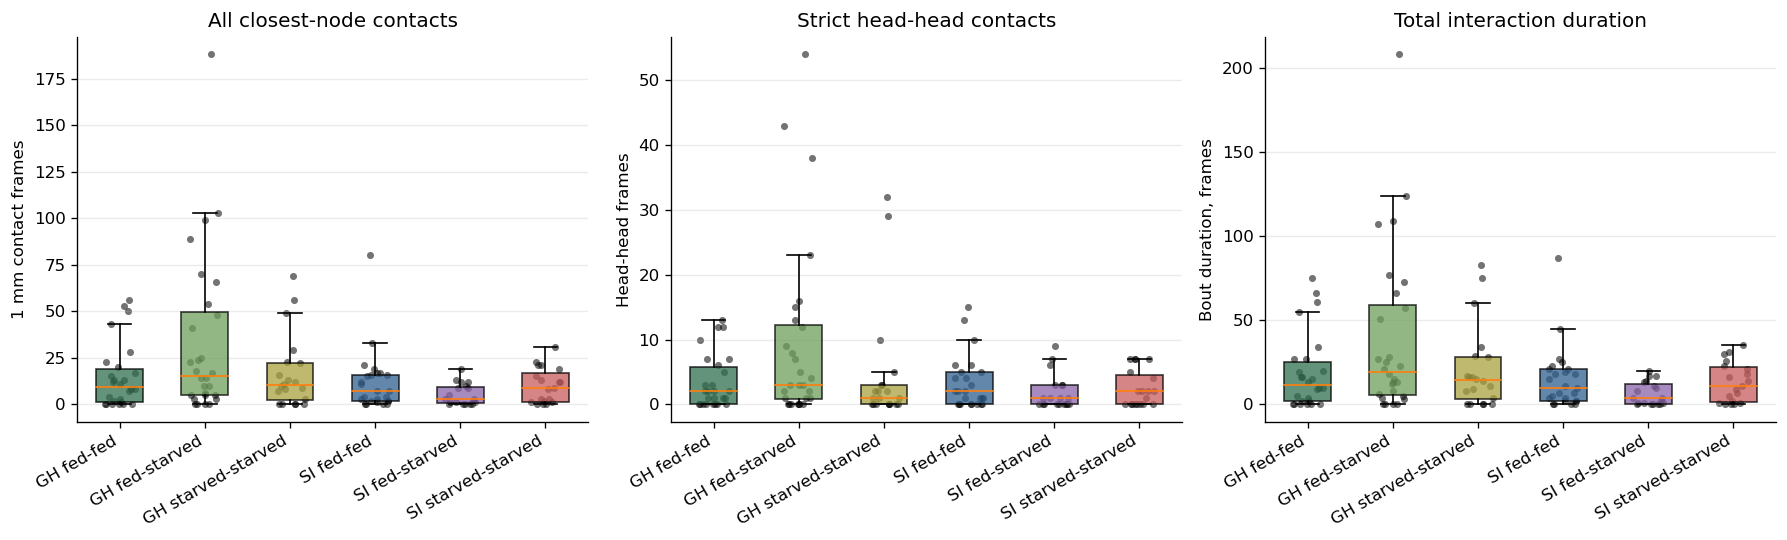

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
box_strip(per_file, 'condition', 'contact_frames_1mm', CONDITION_ORDER, PALETTE, axes[0], '1 mm contact frames', 'All closest-node contacts')
box_strip(per_file, 'condition', 'head_head_frames_1mm', CONDITION_ORDER, PALETTE, axes[1], 'Head-head frames', 'Strict head-head contacts')
box_strip(per_file, 'condition', 'total_bout_duration', CONDITION_ORDER, PALETTE, axes[2], 'Bout duration, frames', 'Total interaction duration')
plt.tight_layout()
plt.show()

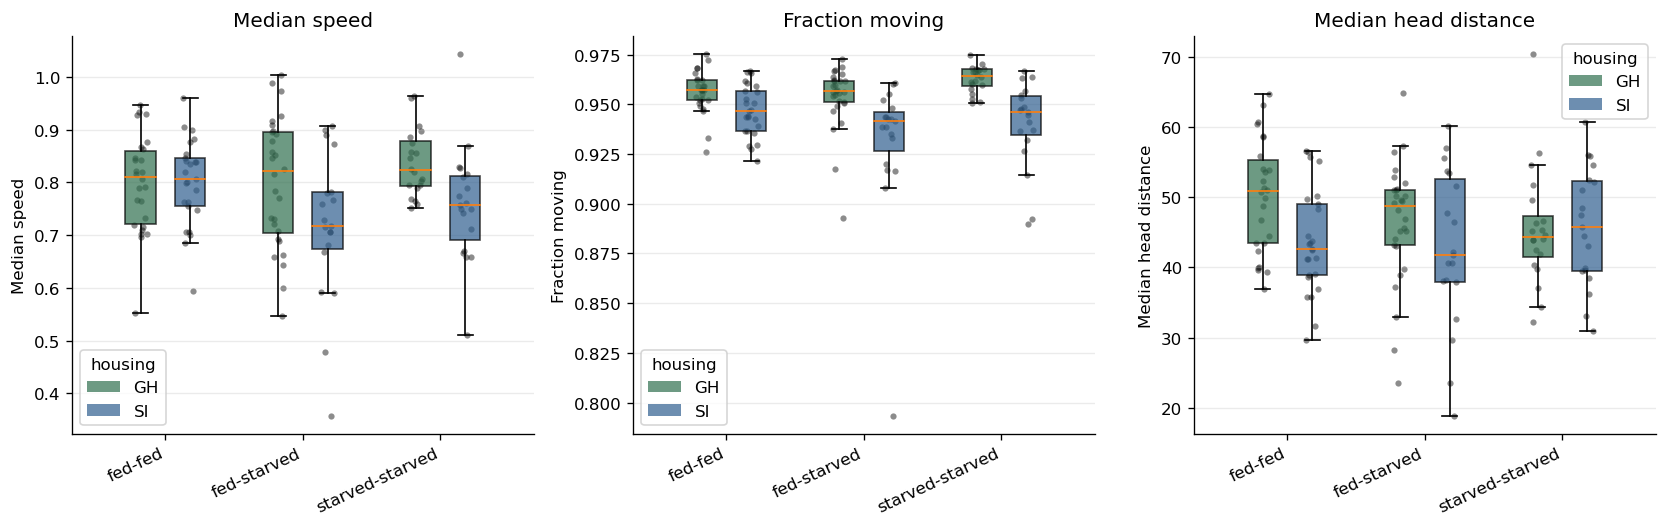

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
grouped_box_strip(per_file, 'feeding', 'housing', 'median_speed', FEEDING_ORDER, ['GH', 'SI'], PALETTE, axes[0], 'Median speed', 'Median speed')
grouped_box_strip(per_file, 'feeding', 'housing', 'moving_fraction', FEEDING_ORDER, ['GH', 'SI'], PALETTE, axes[1], 'Fraction moving', 'Fraction moving')
grouped_box_strip(per_file, 'feeding', 'housing', 'median_head_distance', FEEDING_ORDER, ['GH', 'SI'], PALETTE, axes[2], 'Median head distance', 'Median head distance')
plt.tight_layout()
plt.show()

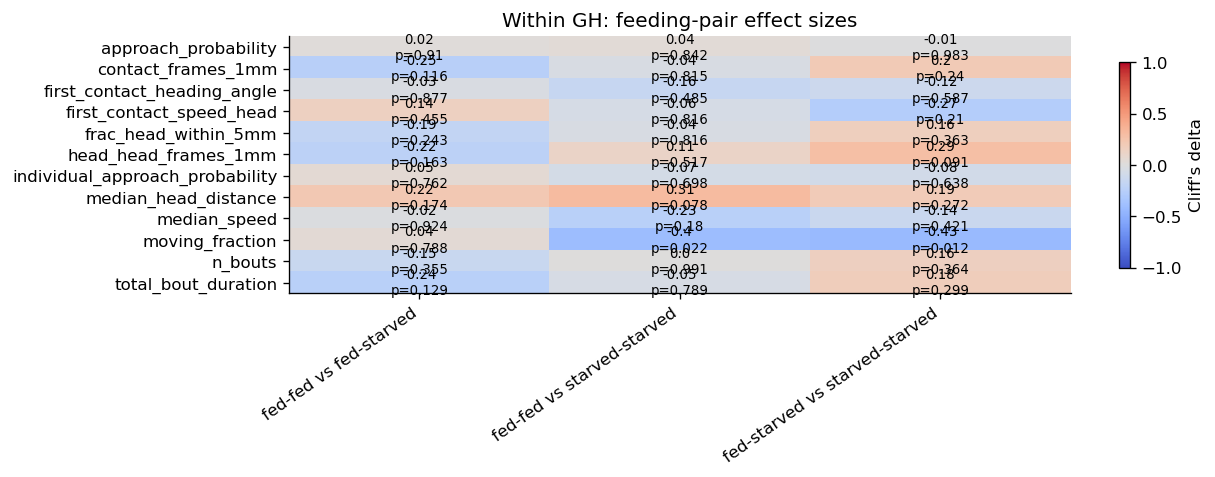

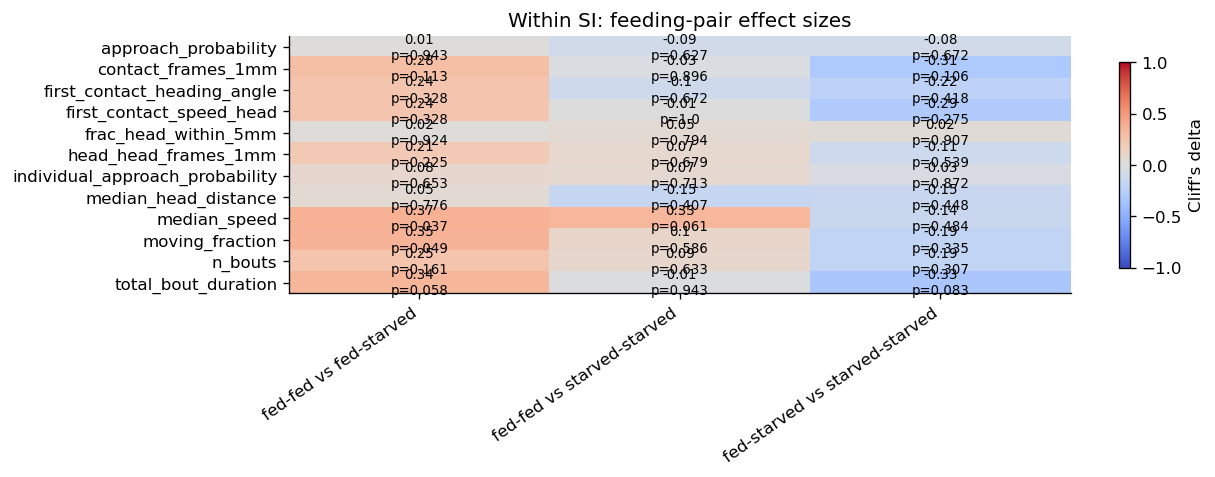

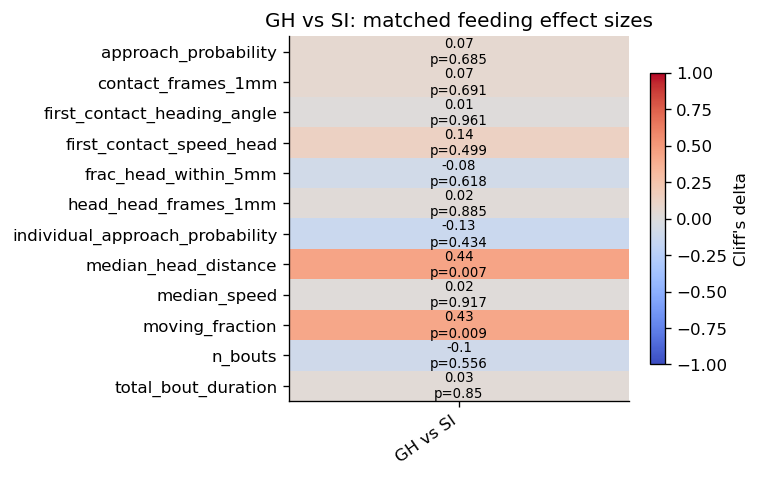

In [8]:
def comparison_heatmap(stats, title):
    if stats.empty:
        print(f'No stats for {title}')
        return
    plot_df = stats.copy()
    plot_df['effect_label'] = plot_df['cliffs_delta'].round(2).astype(str) + '\np=' + plot_df['p_mwu'].round(3).astype(str)
    pivot = plot_df.pivot_table(index='metric', columns='comparison', values='cliffs_delta', aggfunc='first')
    labels = plot_df.pivot_table(index='metric', columns='comparison', values='effect_label', aggfunc='first').reindex_like(pivot)
    fig_height = max(4, 0.34 * len(pivot.index))
    fig_width = min(15, 2.25 * len(pivot.columns) + 4)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    im = ax.imshow(pivot.values, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            text = labels.iloc[i, j]
            if pd.notna(text):
                ax.text(j, i, text, ha='center', va='center', fontsize=8)
    ax.set_xticks(np.arange(pivot.shape[1]))
    ax.set_xticklabels(pivot.columns, rotation=35, ha='right')
    ax.set_yticks(np.arange(pivot.shape[0]))
    ax.set_yticklabels(pivot.index)
    ax.set_title(title)
    cbar = fig.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label("Cliff's delta")
    plt.tight_layout()
    plt.show()

heatmap_metrics = comparison_metrics[:12]
comparison_heatmap(gh_within[gh_within['metric'].isin(heatmap_metrics)], 'Within GH: feeding-pair effect sizes')
comparison_heatmap(si_within[si_within['metric'].isin(heatmap_metrics)], 'Within SI: feeding-pair effect sizes')
comparison_heatmap(between[between['metric'].isin(heatmap_metrics)], 'GH vs SI: matched feeding effect sizes')

In [9]:
interesting_between = between.sort_values(['p_mwu', 'abs_cliffs_delta'], ascending=[True, False]).head(12)
interesting_within = pd.concat([
    gh_within.assign(scope='within GH'),
    si_within.assign(scope='within SI'),
], ignore_index=True).sort_values(['p_mwu', 'abs_cliffs_delta'], ascending=[True, False]).head(12)

print('Best GH-vs-SI talking points')
display(interesting_between[[
    'feeding', 'metric', 'comparison', 'median_a', 'median_b', 'delta_median',
    'p_mwu', 'p_bh', 'cliffs_delta', 'n_a', 'n_b',
]].round(4))

print('Best within-housing talking points')
display(interesting_within[[
    'scope', 'metric', 'comparison', 'median_a', 'median_b', 'delta_median',
    'p_mwu', 'p_bh', 'cliffs_delta', 'n_a', 'n_b',
]].round(4))

Best GH-vs-SI talking points


,feeding,metric,comparison,median_a,median_b,delta_median,p_mwu,p_bh,cliffs_delta,n_a,n_b
28,starved-starved,moving_fraction,GH vs SI,0.9643,0.9460,0.0184,0.0000,0.0004,0.7842,20,19
14,fed-starved,moving_fraction,GH vs SI,0.9565,0.9415,0.0150,0.0002,0.0033,0.6391,28,19
15,fed-starved,contact_frames_1mm,GH vs SI,15.5000,3.0000,12.5000,0.0025,0.0116,0.5244,28,19
16,fed-starved,total_bout_duration,GH vs SI,19.5000,4.0000,15.5000,0.0025,0.0116,0.5244,28,19
29,starved-starved,median_speed,GH vs SI,0.8228,0.7569,0.0659,0.0036,0.0255,0.5474,20,19
0,fed-fed,median_head_distance,GH vs SI,50.8563,42.6051,8.2512,0.0069,0.0634,0.4431,26,25
1,fed-fed,moving_fraction,GH vs SI,0.9573,0.9467,0.0106,0.0091,0.0634,0.4277,26,25
17,fed-starved,head_head_frames_1mm,GH vs SI,3.0000,1.0000,2.0000,0.0193,0.0675,0.3985,28,19
18,fed-starved,median_speed,GH vs SI,0.8212,0.7168,0.1044,0.0579,0.1620,0.3308,28,19
2,fed-fed,any_left,GH vs SI,0.0000,1.0000,-1.0000,0.0712,0.3321,-0.2508,26,25


Best within-housing talking points


,scope,metric,comparison,median_a,median_b,delta_median,p_mwu,p_bh,cliffs_delta,n_a,n_b
0,within GH,moving_fraction,fed-starved vs starved-starved,0.9565,0.9643,-0.0079,0.0124,0.4582,-0.4286,28,20
1,within GH,moving_fraction,fed-fed vs starved-starved,0.9573,0.9643,-0.0071,0.0218,0.4582,-0.4000,26,20
42,within SI,median_speed,fed-fed vs fed-starved,0.8066,0.7168,0.0898,0.0371,0.5276,0.3726,25,19
43,within SI,moving_fraction,fed-fed vs fed-starved,0.9467,0.9415,0.0052,0.0492,0.5276,0.3516,25,19
44,within SI,total_bout_duration,fed-fed vs fed-starved,10.0000,4.0000,6.0000,0.0583,0.5276,0.3368,25,19
45,within SI,median_speed,fed-fed vs starved-starved,0.8066,0.7569,0.0497,0.0612,0.5276,0.3347,25,19
2,within GH,median_head_distance,fed-fed vs starved-starved,50.8563,44.2762,6.5801,0.0781,0.8403,0.3077,26,20
46,within SI,total_bout_duration,fed-starved vs starved-starved,4.0000,11.0000,-7.0000,0.0831,0.5276,-0.3296,19,19
47,within SI,interacted_before_leaving,fed-fed vs starved-starved,0.0000,0.0000,0.0000,0.0875,0.5276,0.2421,25,19
3,within GH,head_head_frames_1mm,fed-starved vs starved-starved,3.0000,1.0000,2.0000,0.0907,0.8403,0.2857,28,20


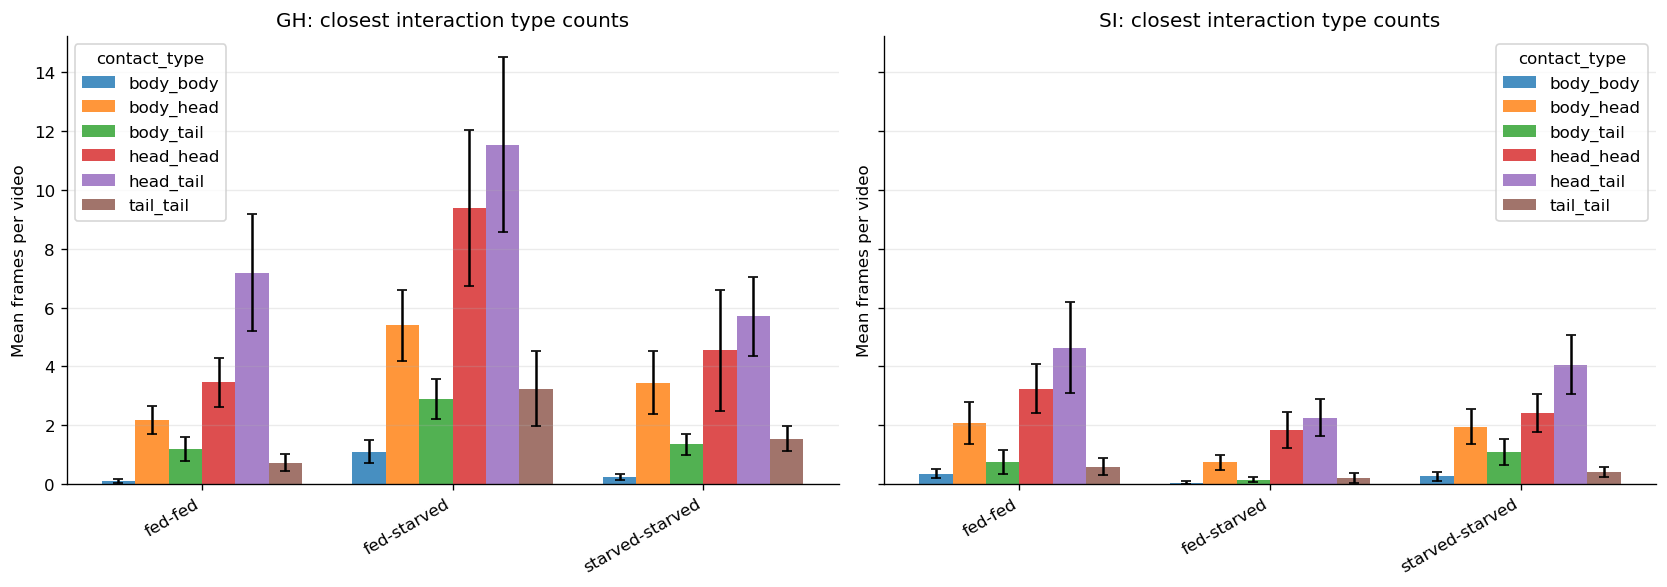

In [10]:
type_cols = [c for c in per_file.columns if c.startswith('closest_type_frames_')]
if type_cols:
    type_long = per_file[['condition', 'housing', 'feeding', 'file'] + type_cols].melt(
        id_vars=['condition', 'housing', 'feeding', 'file'],
        value_vars=type_cols,
        var_name='contact_type', value_name='frames',
    )
    type_long['contact_type'] = type_long['contact_type'].str.replace('closest_type_frames_', '', regex=False)
    type_order = sorted(type_long['contact_type'].unique())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    for ax, housing in zip(axes, ['GH', 'SI']):
        sub = type_long[type_long['housing'].eq(housing)]
        grouped_bar(
            sub, 'feeding', 'contact_type', 'frames', FEEDING_ORDER, type_order,
            colors={t: plt.cm.tab10(i % 10) for i, t in enumerate(type_order)},
            ax=ax, ylabel='Mean frames per video', title=f'{housing}: closest interaction type counts',
        )
    plt.tight_layout()
    plt.show()
else:
    print('No closest interaction type columns found')

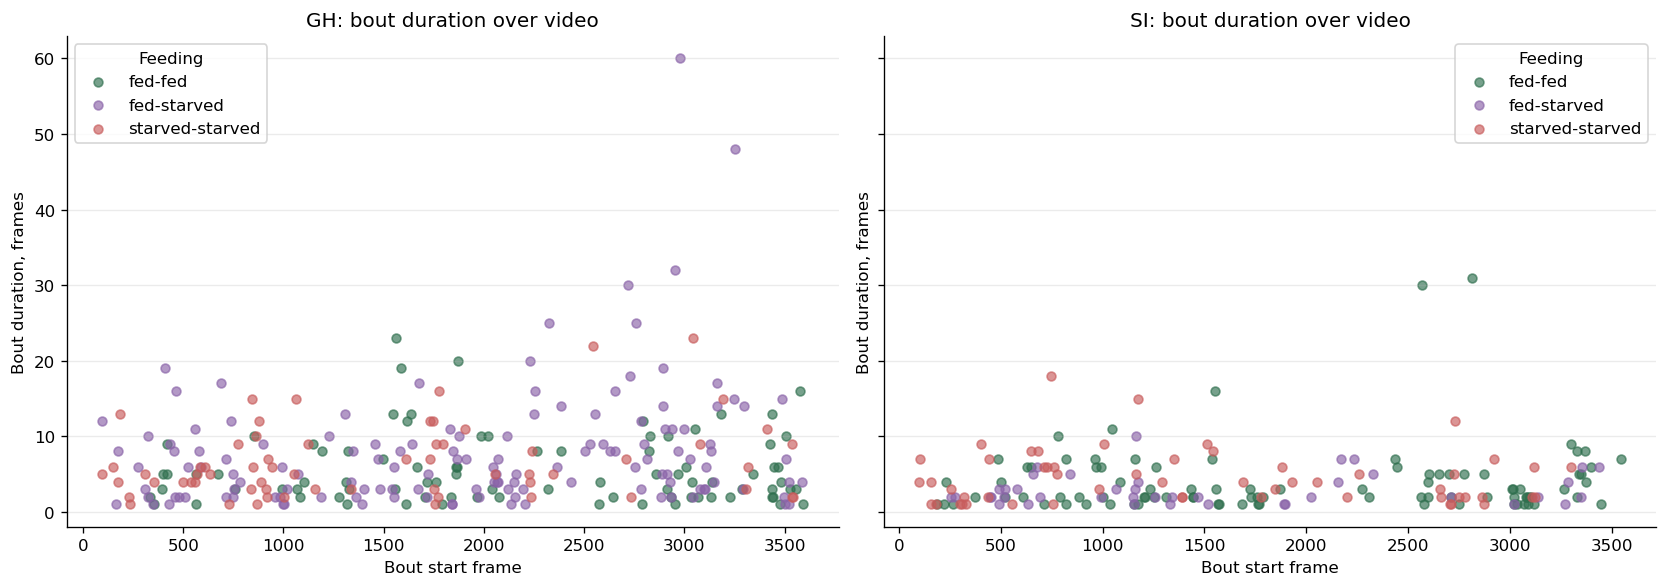

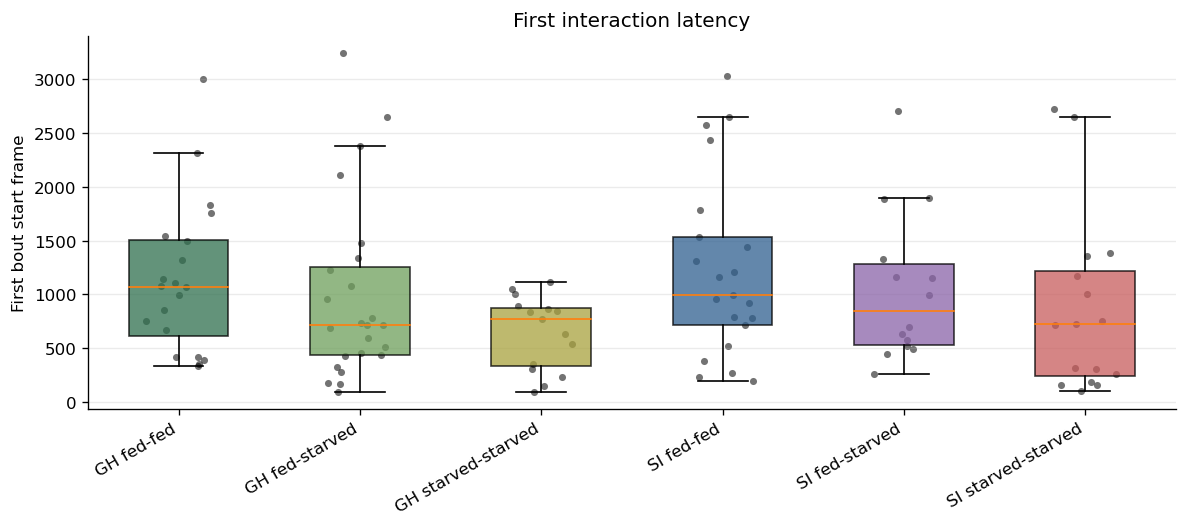

In [11]:
bouts = load_table('interaction_type_bout.csv')
if not bouts.empty:
    bouts = bouts.sort_values(['condition', 'file', 'start_frame'])
    bouts['bout_number'] = bouts.groupby(['condition', 'file']).cumcount() + 1

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    feeding_colors = {'fed-fed': '#2F6F4E', 'fed-starved': '#8A63A8', 'starved-starved': '#C85C5C'}
    for ax, housing in zip(axes, ['GH', 'SI']):
        sub = bouts[bouts['housing'].eq(housing)]
        for feeding in FEEDING_ORDER:
            s = sub[sub['feeding'].eq(feeding)]
            ax.scatter(s['start_frame'], s['duration'], s=28, alpha=0.65, label=feeding, color=feeding_colors[feeding])
        ax.set_title(f'{housing}: bout duration over video')
        ax.set_xlabel('Bout start frame')
        ax.set_ylabel('Bout duration, frames')
        ax.grid(axis='y', alpha=0.25)
        ax.legend(title='Feeding')
    plt.tight_layout()
    plt.show()

    first_bouts = bouts[bouts['bout_number'].eq(1)]
    fig, ax = plt.subplots(figsize=(10, 4.5))
    box_strip(first_bouts, 'condition', 'start_frame', CONDITION_ORDER, PALETTE, ax, 'First bout start frame', 'First interaction latency')
    plt.tight_layout()
    plt.show()
else:
    print('No interaction_type_bout.csv data found')

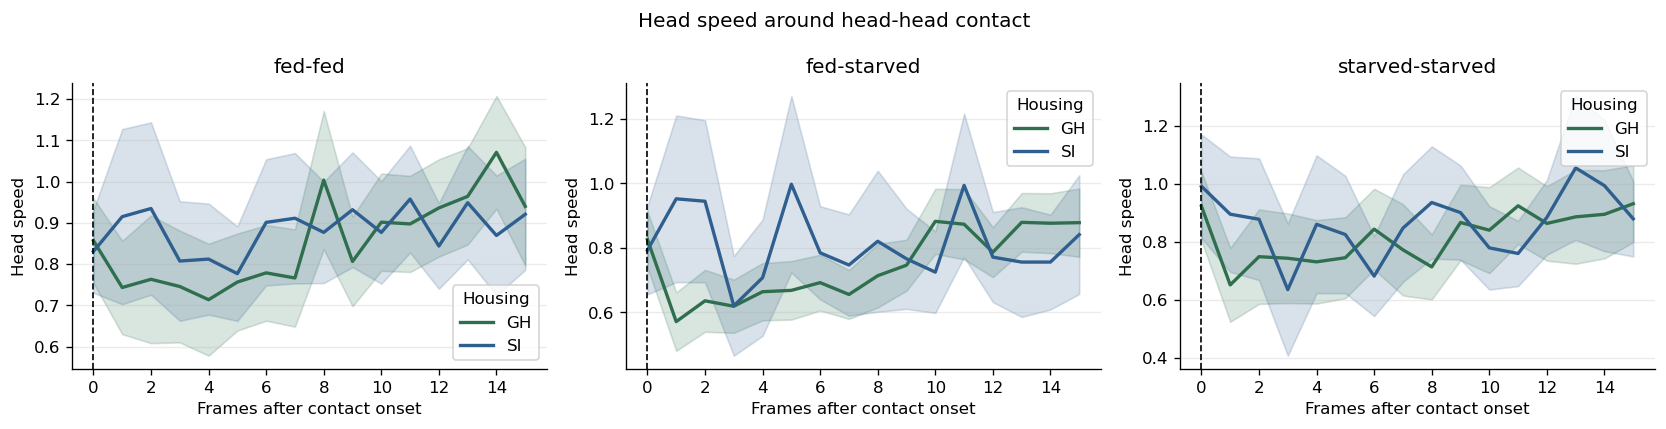

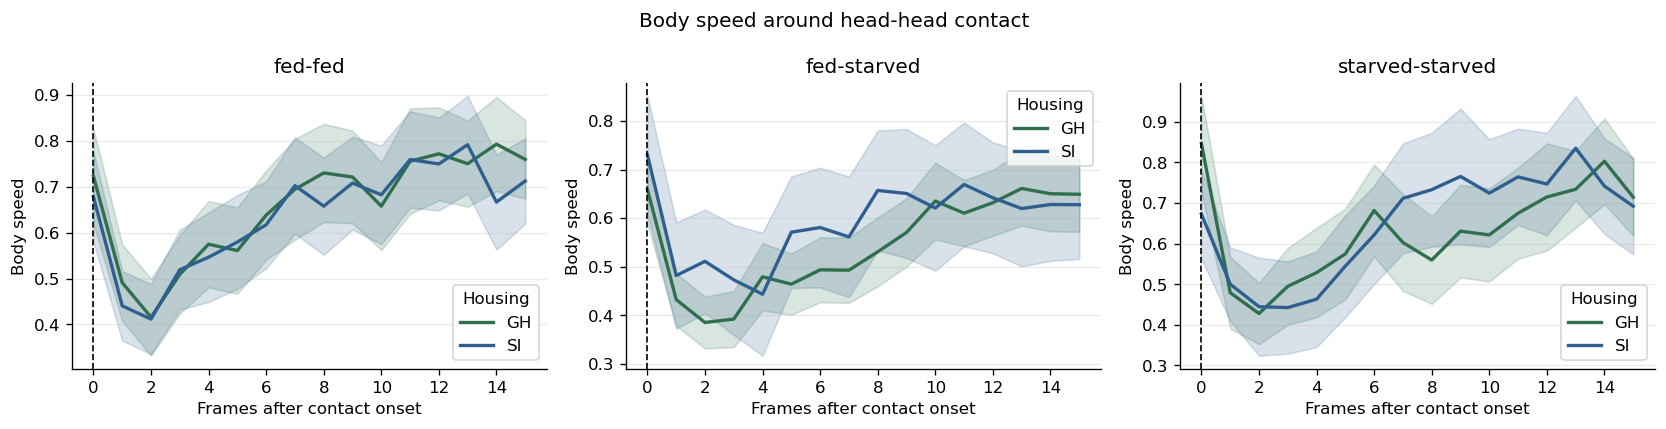

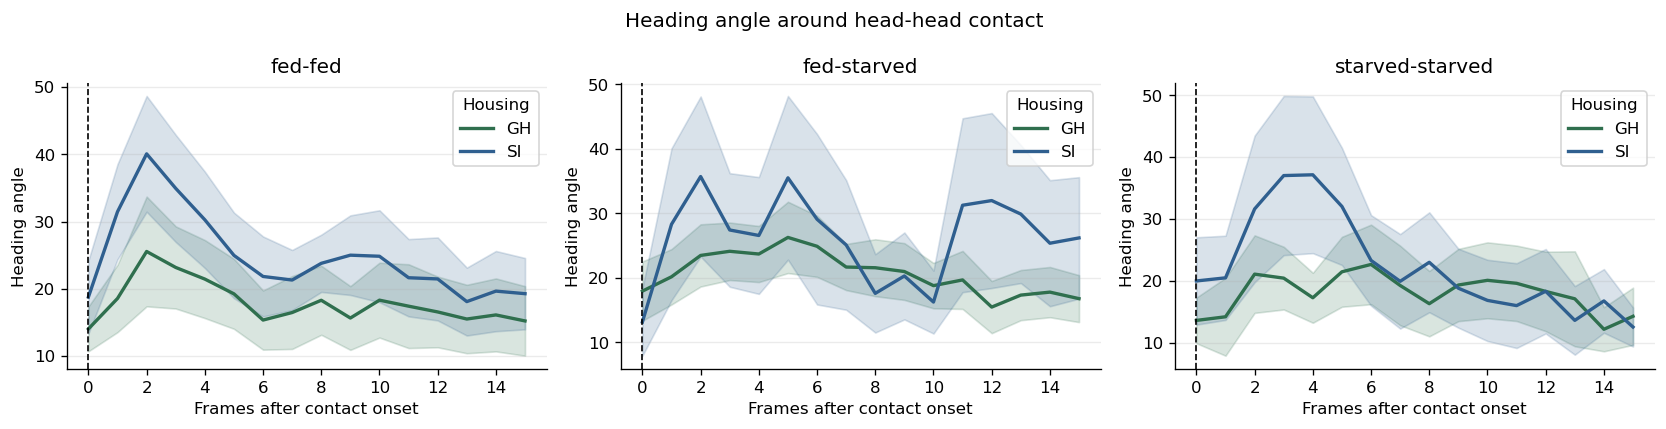

In [12]:
kin = load_table('head_head_contacts_kinematics_over_time.csv')
if not kin.empty:
    kin_window = kin[(kin['rel_frame'] >= 0) & (kin['rel_frame'] <= 20)].copy()
    for metric, label in [('speed_head', 'Head speed'), ('speed_body', 'Body speed'), ('heading_angle', 'Heading angle')]:
        fig, axes = plt.subplots(1, 3, figsize=(14, 3.6), sharey=False)
        for ax, feeding in zip(axes, FEEDING_ORDER):
            sub = kin_window[kin_window['feeding'].eq(feeding)]
            line_ci(sub, 'rel_frame', metric, 'housing', ['GH', 'SI'], PALETTE, ax)
            ax.axvline(0, color='black', linestyle='--', linewidth=1)
            ax.set_title(feeding)
            ax.set_xlabel('Frames after contact onset')
            ax.set_ylabel(label)
            ax.legend(title='Housing')
        fig.suptitle(f'{label} around head-head contact')
        plt.tight_layout()
        plt.show()
else:
    print('No head_head_contacts_kinematics_over_time.csv data found')

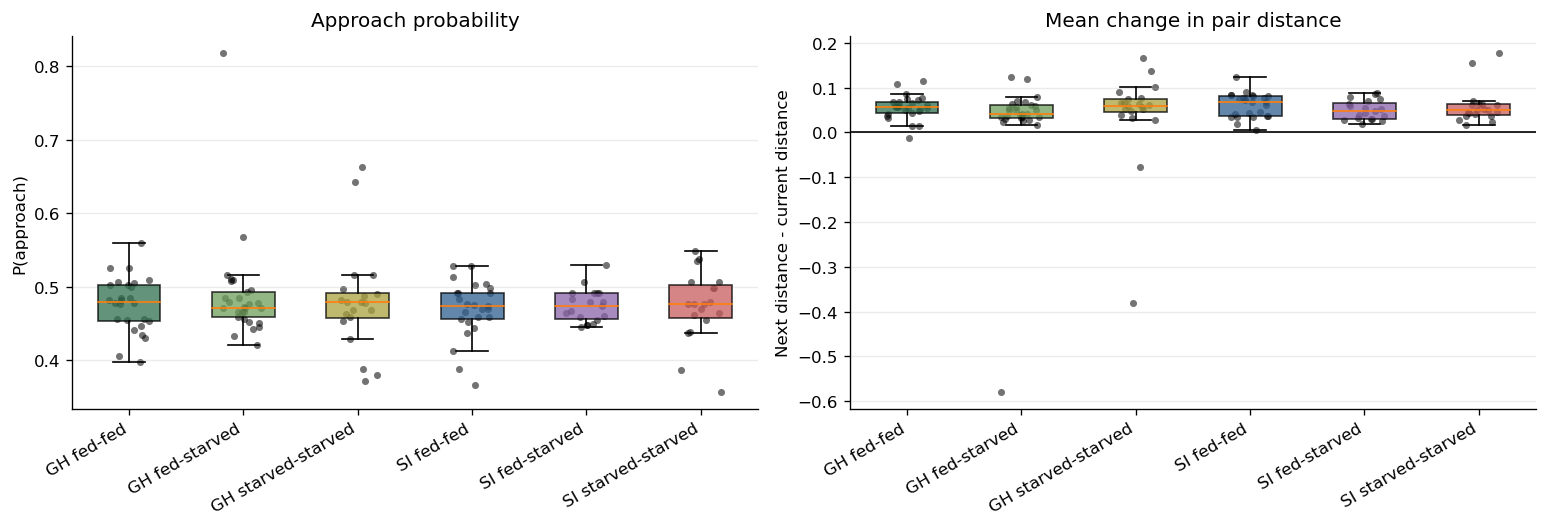

In [13]:
pairwise = load_table('pairwise_approach_probability.csv')
if not pairwise.empty:
    pairwise_file = pairwise.groupby(['housing', 'feeding', 'condition', 'file']).agg(
        approach_probability=('approach', 'mean'),
        mean_delta_distance=('delta_distance', 'mean'),
        median_distance=('distance', 'median'),
    ).reset_index()

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    box_strip(pairwise_file, 'condition', 'approach_probability', CONDITION_ORDER, PALETTE, axes[0], 'P(approach)', 'Approach probability')
    box_strip(pairwise_file, 'condition', 'mean_delta_distance', CONDITION_ORDER, PALETTE, axes[1], 'Next distance - current distance', 'Mean change in pair distance')
    axes[1].axhline(0, color='black', linewidth=1)
    plt.tight_layout()
    plt.show()
else:
    print('No pairwise_approach_probability.csv data found')

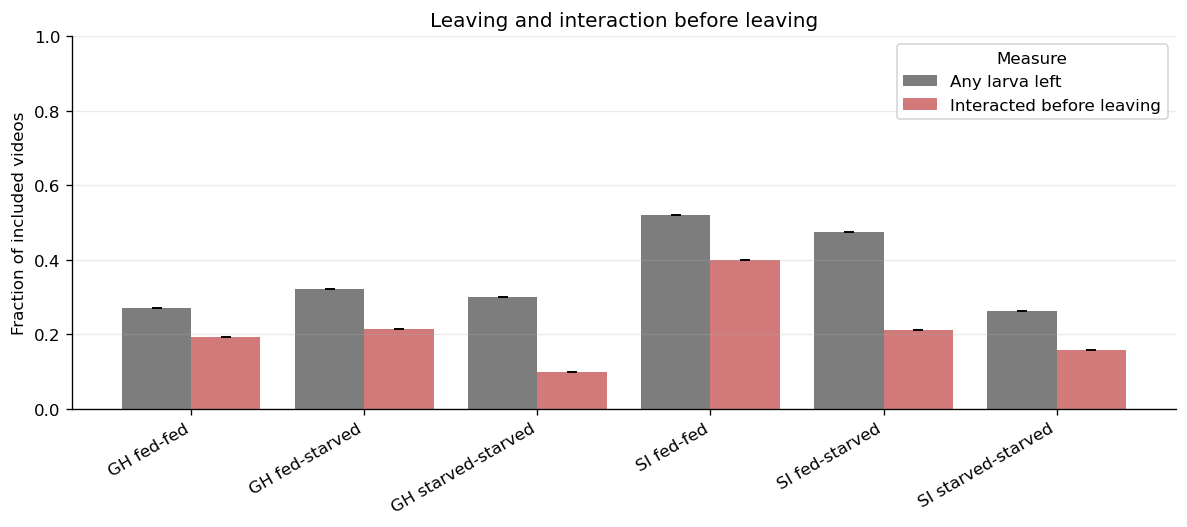

In [14]:
leaving_cols = ['any_left', 'interacted_before_leaving']
leaving = per_file.groupby(['housing', 'feeding', 'condition'])[leaving_cols].mean().reset_index()
leaving_long = leaving.melt(
    id_vars=['housing', 'feeding', 'condition'], value_vars=leaving_cols,
    var_name='measure', value_name='fraction',
)
measure_order = ['any_left', 'interacted_before_leaving']
fig, ax = plt.subplots(figsize=(10, 4.5))
grouped_bar(
    leaving_long, 'condition', 'measure', 'fraction', CONDITION_ORDER, measure_order,
    colors={'any_left': '#606060', 'interacted_before_leaving': '#C85C5C'},
    ax=ax, ylabel='Fraction of included videos', title='Leaving and interaction before leaving',
)
ax.set_ylim(0, 1)
ax.legend(title='Measure', labels=['Any larva left', 'Interacted before leaving'])
plt.tight_layout()
plt.show()

## Notes to keep honest

- This is exploratory. Treat raw p-values as a ranking aid; the effect sizes and plots are more useful for deciding what to inspect next.
- `contact_frames_1mm` counts closest-node contact rows within 1 mm, while `head_head_frames_1mm` is stricter and only counts rows labelled `head_head`.
- Files with no contacts are kept as zeros for count/duration metrics, but kinematic-at-contact metrics are missing for those files because there was no contact event to summarize.
- If the frame rate is needed for seconds, check the acquisition setting first. The notebook currently leaves latency and duration in frames.